# Actividad práctica: Segmentación de clientes mediante clustering

En esta actividad se trabajará con un conjunto de datos de clientes con el objetivo de identificar segmentos con características similares mediante técnicas de agrupamiento.

La segmentación se construirá utilizando **edad** e **ingreso anual**, dos variables cuantitativas que permiten trabajar directamente con distancias y visualizar los resultados en dos dimensiones. Las demás variables del conjunto de datos se utilizarán posteriormente para **caracterizar e interpretar** los grupos encontrados.

Se aplicarán dos métodos vistos en la unidad:

- K-Means.
- Agrupamiento jerárquico aglomerativo.

Para evaluar las soluciones se utilizarán la inercia o WCSS, el método del codo y el índice de silueta.

## Descripción del conjunto de datos

El siguiente conjunto de datos consiste en información sobre el comportamiento de compra de 2,000 individuos de una determinada área al entrar en una tienda física de bienes de consumo rápido. Todos los datos se han recopilado a través de las tarjetas que utilizan al momento de pagar. Los datos han sido preprocesados y no hay valores faltantes. Además, el volumen del conjunto de datos se ha limitado y anonimizado para proteger la privacidad de los clientes.

Columnas del conjunto de datos:

- **Sex**: género.  
  0: masculino,  
  1: femenino.
- **Marital status**: estado civil de un cliente.  
  0: soltero,  
  1: no soltero (divorciado/separado/casado/viudo).
- **Age**: edad del cliente en años. Valor mínimo: 18, valor máximo: 78.
- **Education**: nivel educativo del cliente.  
  0: otro/desconocido,  
  1: escuela secundaria,  
  2: universidad,  
  3: posgrado.
- **Income**: ingreso anual autoreportado en dólares estadounidenses del cliente. Valor mínimo: 35,832, valor máximo: 309,364.
- **Occupation**: categoría de la ocupación del cliente.  
  0: desempleado/no calificado,  
  1: empleado calificado/funcionario,  
  2: administración/autónomo/empleado altamente calificado/oficial.
- **Settlement size**: tamaño de la ciudad donde vive el cliente.  
  0: ciudad pequeña,  
  1: ciudad mediana,  
  2: gran ciudad.

In [35]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.datasets import make_blobs, make_moons
from IPython.display import display
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler
from matplotlib.ticker import FixedLocator, FixedFormatter

RANDOM_STATE = 42

### 1. Exploración inicial

Antes de aplicar un algoritmo de clustering, analice la estructura del conjunto de datos `customer_data.csv` y analice las variables `Age` e `Income` mediante estadísticos descriptivos. Represente gráficamente la relación entre edad e ingreso.

¿Se observan grupos claramente separados a simple vista en el plano edad-ingreso?

In [3]:
datos = pd.read_csv("./customer_data.csv", sep=",")
datos.head()

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,100000001,0,0,67,2,124670,1,2
1,100000002,1,1,22,1,150773,1,2
2,100000003,0,0,49,1,89210,0,0
3,100000004,0,0,45,1,171565,1,1
4,100000005,0,0,53,1,149031,1,1


In [8]:
edad = datos["Age"].describe()
edad

count    2000.000000
mean       35.909000
std        11.719402
min        18.000000
25%        27.000000
50%        33.000000
75%        42.000000
max        76.000000
Name: Age, dtype: float64

In [9]:
ingreso = datos["Income"].describe()
ingreso

count      2000.000000
mean     120954.419000
std       38108.824679
min       35832.000000
25%       97663.250000
50%      115548.500000
75%      138072.250000
max      309364.000000
Name: Income, dtype: float64

<Axes: title={'center': 'Diagrama de dispersión'}, xlabel='Age', ylabel='Income'>

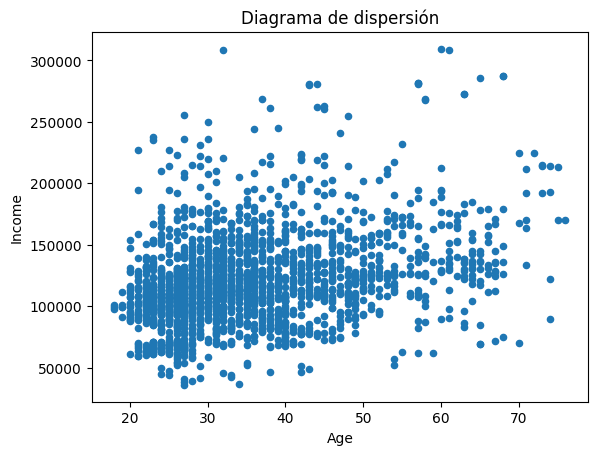

In [17]:
datos.plot(kind="scatter", x = "Age", y = "Income", title = "Diagrama de dispersión")

No hay grupos separados

### 2. Selección de características y escalado

Para construir los clusters se utilizarán únicamente:

$$
X = [\text{Age},\text{Income}]
$$

Las demás variables se reservarán para describir los segmentos una vez obtenidos.

In [14]:
datos_ei = datos[["Age", "Income"]]
datos_ei

,Age,Income
0,67,124670
1,22,150773
2,49,89210
3,45,171565
4,53,149031
...,...,...
1995,47,123525
1996,27,117744
1997,31,86400
1998,24,97968


### 3. Selección del número de clusters con K-Means

No se conoce de antemano cuántos grupos existen en los datos.

1. Ajuste K-Means para valores de $K$ entre 1 y 10.
2. Registre la inercia o WCSS para cada valor de $K$.
3. Para $K \geq 2$, calcule además el coeficiente de silueta promedio.
4. Represente:
   - WCSS en función de $K$.
   - coeficiente de silueta promedio en función de $K$.
5. Identifique los valores de $K$ que considera más razonables y justifique.

In [38]:
# Agrupamos los datos en clusters usando KMeans
X_edad, y_ingreso = make_blobs(n_samples=600, centers=3, cluster_std=[1.0, 2.0, 0.8], random_state=42)

# Escalamos los datos usando StandardScaler
scaler = StandardScaler()
X_sc = scaler.fit_transform(X_edad)

In [ ]:
inercia = []
# Ajustamos el modelo KMeans para diferentes valores de k (número de clusters)
for k in range(1, 11):
    kmeans_sc = KMeans(n_clusters= k, n_init=10, random_state=1)
    labels_sc = kmeans_sc.fit_predict(X_sc)
    centers_sc = kmeans_sc.cluster_centers_
    inercia.append(kmeans_sc.inertia_) # guardamos la inercia (WCSS) para cada valor de k
print("Inercia (WCSS) con escalado:", inercia)

Inercia (WCSS) con escalado: [1200.0000000000005, 400.5003482843948, 71.64932998355135, 51.438373812339435, 42.01003757526163, 36.611864362072566, 31.733069668243445, 27.92311468809489, 24.919290687792934, 23.275167595291425]


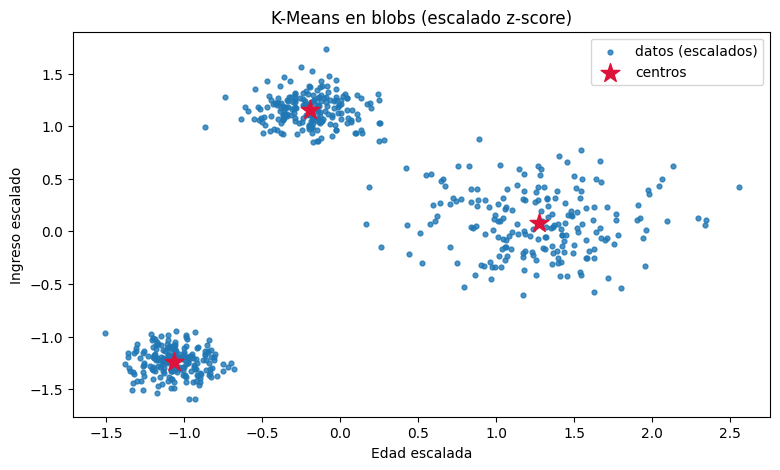

In [ ]:
# Graficamos el cluster resultante con KMeans para k=3
kmeans_scaled = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_scaled = kmeans_scaled.fit_predict(X_sc)
plt.figure(figsize=(9, 5))
plt.scatter(X_sc[:, 0], X_sc[:, 1], s=12, alpha=0.8, label="datos (escalados)")
centers_scaled = kmeans_scaled.cluster_centers_
plt.scatter(centers_scaled[:, 0], centers_scaled[:, 1], marker="*", s=200, label="centros", color = "crimson")
plt.title("K-Means en blobs (escalado z-score)")
plt.xlabel("Edad escalada"); plt.ylabel("Ingreso escalado")
plt.legend()
plt.show()

In [ ]:
# Calculamos los promedios de los coeficientes de silueta
silhouette_scores = [silhouette_score(X_sc, model.labels_) for model in kmeans_per_k[1:]] #por lo menos 2 clusters
silhouette_scores

[0.7902109997733658,
 0.6794112016995011,
 0.6707256117131878,
 0.6740880899799633,
 0.5356568768843669,
 0.538290136201178,
 0.3571834169752888,
 0.345380699844366]

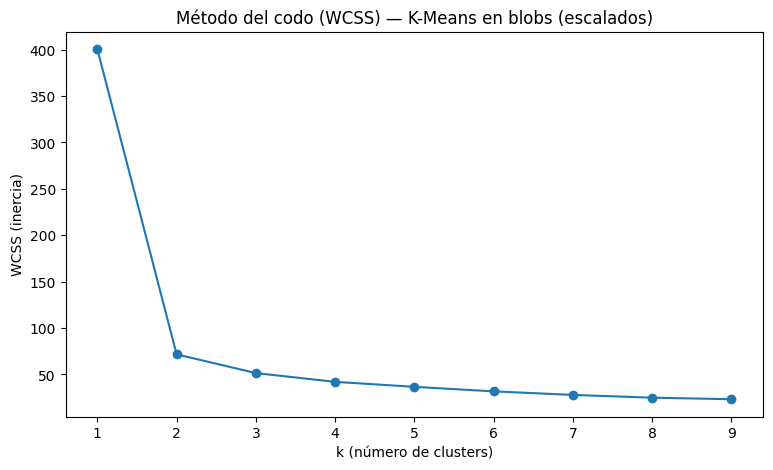

In [ ]:
# Representamos WCSS en función de k para el método del codo
kmeans_per_k = [ KMeans(n_clusters=k, n_init=10, random_state=1).fit(X_sc) for k in range(2, 11) ]
wcss_per_k = [model.inertia_ for model in kmeans_per_k]

plt.figure(figsize=(9, 5))
plt.plot(list(range(1, 10)), wcss_per_k, marker="o")
plt.title("Método del codo (WCSS) — K-Means en blobs (escalados)")
plt.xlabel("k (número de clusters)"); plt.ylabel("WCSS (inercia)")
plt.show()

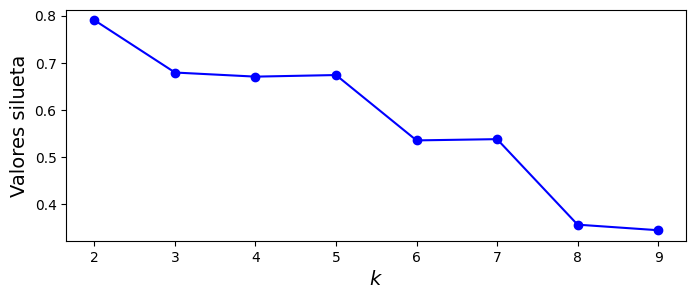

In [ ]:
# Representamos los coeficientes de silueta para cada valor de k
plt.figure(figsize=(8, 3))
plt.plot(range(2, 10), silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Valores silueta", fontsize=14)
plt.show()

Creemos que el 2

### 4. Análisis de los diagramas de silueta

El coeficiente promedio resume el resultado en un único número, pero no permite observar cómo se comportan las observaciones dentro de cada cluster.

Construya diagramas de silueta para $K=2$, $K=3$, $K=4$ y $k=5$.

Interprételo de acuerdo a los criterios vistos en la notebook de práctica.

Utilice esta información para complementar la elección de $K$.

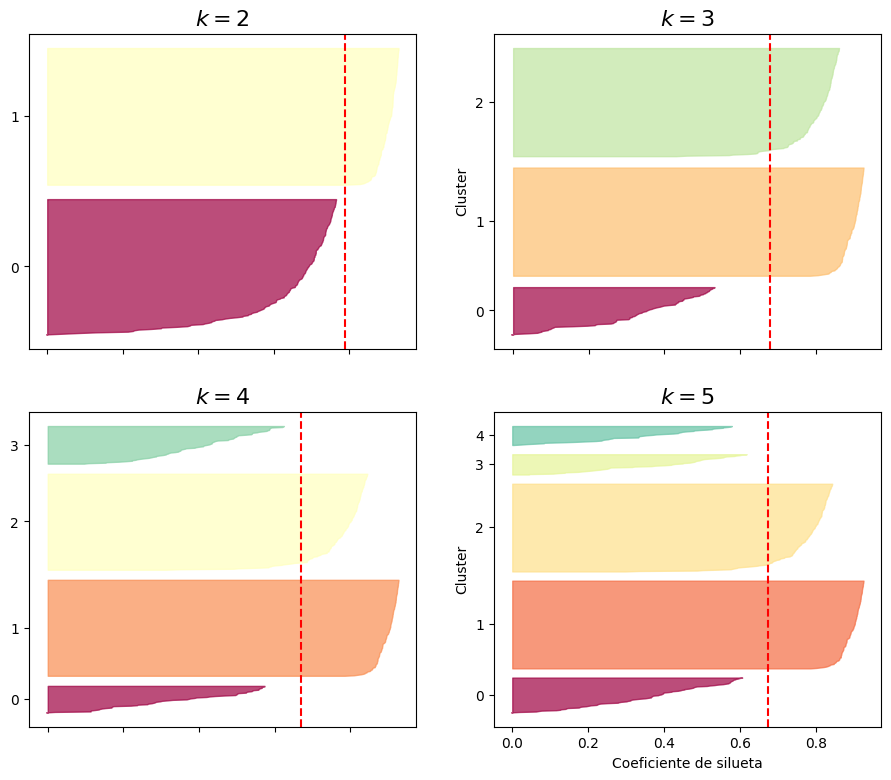

In [54]:
plt.figure(figsize=(11, 9))

for k in (2, 3, 4, 5):
    plt.subplot(2, 2, k - 1)

    y_pred = kmeans_per_k[k - 1].labels_ #etiquetas de cada instancia de X
    silhouette_coefficients = silhouette_samples(X_sc, y_pred) #coeficientes para cada una de las instancias en X

    padding = len(X_edad) // 30

    pos = padding
    ticks = []
    #Grafico los coeficientes de silueta por cada cluster
    for i in range(k): #i = 0,1,2..
        coeffs = silhouette_coefficients[y_pred == i] #coeficientes correspondientes a un cluster específico
        coeffs.sort()

        color = mpl.cm.Spectral(i / k) #colormap
        plt.fill_betweenx(y = np.arange(pos, pos + len(coeffs)), x1=0, x2=coeffs, facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))

    if k in (3, 5):
        plt.ylabel("Cluster")

    if k in (5, 6):
        # plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Coeficiente de silueta")
    else:
        plt.tick_params(labelbottom=False)

    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title("$k={}$".format(k), fontsize=16)

plt.show()

### Interpretacion de los diagramas de silueta

Se puede observar que el valor de K mas optimo es K = 3, ya que tiene un promedio alto, pocos valores negativos y cluster con coeficientes de siluetas razonablementes altos.

### 5. Segmentación final con K-Means

Ajuste un modelo K-Means utilizando el valor de K seleccionado.

1. Obtenga la etiqueta asignada a cada cliente.
2. Represente los clusters utilizando las variables originales `Age` e `Income`.
3. Calcule los centroides y represéntelos en el gráfico.
4. Interprete qué representan los grupos obtenidos.

Recuerde que los números asignados a los clusters son identificadores arbitrarios: `Cluster 0` no implica que ese grupo sea menor o más importante que `Cluster 1`.

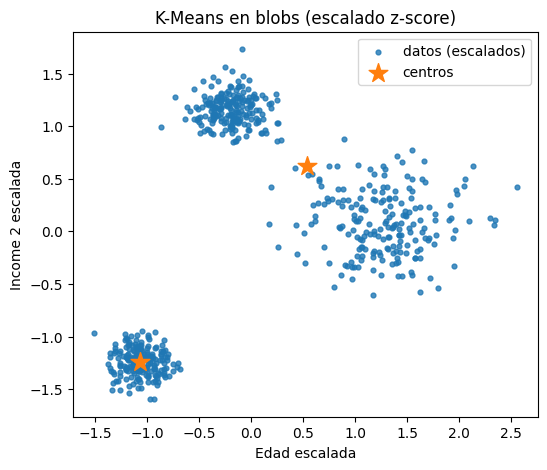

Inercia (WCSS) con escalado: 400.5003482843948


In [57]:
# Ajustamos el modelo KMeans para k=2 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_edad)

kmeans_scaled2 = KMeans(n_clusters=2, n_init=10, random_state=42)
labels_scaled2 = kmeans_scaled2.fit_predict(X_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], s=12, alpha=0.8, label="datos (escalados)")
centers_2 = kmeans_scaled2.cluster_centers_
plt.scatter(centers_2[:, 0], centers_2[:, 1], marker="*", s=200, label="centros")
plt.title("K-Means en blobs (escalado z-score)")
plt.xlabel("Edad escalada"); plt.ylabel("Income 2 escalada")
plt.legend()
plt.show()

print("Inercia (WCSS) con escalado:", kmeans_scaled2.inertia_)

### 6. Caracterización de los segmentos

Agregue las etiquetas de K-Means al conjunto de datos original y describa cada cluster utilizando las características disponibles.

Para cada grupo analice:

- cantidad de clientes;
- edad media y mediana;
- ingreso medio y mediano;
- distribución por género;
- estado civil;
- nivel educativo;
- ocupación;
- tamaño de la ciudad de residencia.

A partir de estos resultados, elabore una descripción breve de cada segmento. Puede utilizar herramientas de `pandas` para esta tarea.

### 7. Agrupamiento jerárquico aglomerativo

Aplique agrupamiento jerárquico sobre las mismas variables estandarizadas.

1. Construya un dendrograma utilizando distancia Euclídea y enlace completo (`complete`).
2. Analice las últimas fusiones del árbol y proponga un nivel de corte.
3. Obtenga una partición con un número de clusters igual al obtenido con k-means.
4. Calcule el coeficiente de silueta para ese número de clusters.
5. Compare visualmente esta solución con la obtenida mediante K-Means.

### 8. Análisis final

A partir de todo el procedimiento, responda:

1. ¿Qué valor de $K$ considera más adecuado para K-Means? Fundamente utilizando WCSS, silueta e interpretación de los clusters.
2. ¿Qué perfiles de clientes identifica?
3. ¿Qué diferencias encuentra entre K-Means y el agrupamiento jerárquico?
4. ¿Qué limitación introduce construir los clusters únicamente con `Age` e `Income`?
5. ¿Por qué no sería correcto afirmar que los clusters encontrados son las únicas categorías posibles de clientes?